# Movie Recommendation System - NMF Collaborative Filtering (Tier 2)
## Group 5 - AIL303m - Machine Learning | FPT University

**Syllabus Mapping:**
- 14. Supervised Learning
- 18. Matrix Factorization / Dimensionality Reduction
- 19. Model Evaluation & Cross-Validation

**Objective:** Implement NMF-based Collaborative Filtering, aim to surpassing the Popularity-based baseline.

**Key Concepts:**
- NMF factorizes the user-item matrix R into: R ≈ W × H
- Learns latent factors (preferences) for each user and movie
- Predicts missing ratings to generate personalized recommendations


## Configurations

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from collections import defaultdict, namedtuple
import time
import pickle
import os

from sklearn.decomposition import NMF
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams.update({'figure.figsize': (12, 8), 'figure.dpi': 100})

print('Loaded!')

Loaded!


## 2. Data Loading & Preparation

In [59]:
# data loading
DATA_PATH = '../data/ml-latest-small/'

rating_df = pd.read_csv(DATA_PATH + 'ratings.csv')
movie_df = pd.read_csv(DATA_PATH + 'movies.csv')

print(f'Ratings: {rating_df.shape[0]:,} entries')
print(f'Movies: {movie_df.shape[0]:,} entries')
print(f'Users: {rating_df["userId"].nunique()}')
print(f'Rating scale: {rating_df["rating"].min()} - {rating_df["rating"].max()}')

# Sparsity
n_users = rating_df['userId'].nunique()
n_movies = rating_df['movieId'].nunique()
sparsity = 1 - (len(rating_df) / (n_users * n_movies))
print(f'Matrix sparsity: {sparsity*100:.1f}%')

Ratings: 100,836 entries
Movies: 9,742 entries
Users: 610
Rating scale: 0.5 - 5.0
Matrix sparsity: 98.3%


In [60]:
# train n test split
train_df, test_df = train_test_split(rating_df[['userId', 'movieId', 'rating']], test_size=0.2, random_state=42)

print(f'Training set: {len(train_df):,} ratings')
print(f'Test set: {len(test_df):,} ratings')

print(f'Split ratio: {len(train_df)/(len(train_df)+len(test_df))*100:.0f}% : {len(test_df)/(len(train_df)+len(test_df))*100:.0f}%')

Training set: 80,668 ratings
Test set: 20,168 ratings
Split ratio: 80% : 20%


## 3. NMF Model Training

**NMF Hyperparameters:**
- `n_factors=100` (latent dimensions)
- `max_iter=200` (optimization iterations)
- `init='nndsvda'` (stable non-negative initialization)

**Optimization:** Coordinate Descent (sklearn NMF)

**Objective:** Minimize reconstruction error under non-negativity constraints.


In [61]:
# 3. NMF Model training - Factorization

def fit_nmf_model(ratings_df, n_factors=100, max_iter=200, random_state=42):
    """Fit NMF on user-item rating matrix with mean-imputation for missing values."""
    user_ids = np.sort(ratings_df['userId'].unique())
    movie_ids = np.sort(ratings_df['movieId'].unique())

    user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
    movie_to_idx = {mid: i for i, mid in enumerate(movie_ids)}

    pivot = ratings_df.pivot(index='userId', columns='movieId', values='rating')
    pivot = pivot.reindex(index=user_ids, columns=movie_ids)

    global_mean = float(ratings_df['rating'].mean())
    user_mean = ratings_df.groupby('userId')['rating'].mean().to_dict()
    movie_mean = ratings_df.groupby('movieId')['rating'].mean().to_dict()

    X = pivot.fillna(global_mean).values

    model = NMF(
        n_components=n_factors,
        init='nndsvda',
        random_state=random_state,
        max_iter=max_iter
    )

    W = model.fit_transform(X)
    H = model.components_
    X_hat = W @ H

    return {
        'model': model,
        'user_to_idx': user_to_idx,
        'movie_to_idx': movie_to_idx,
        'X_hat': X_hat,
        'global_mean': global_mean,
        'user_mean': user_mean,
        'movie_mean': movie_mean,
        'n_factors': n_factors,
        'max_iter': max_iter
    }


def predict_rating(state, user_id, movie_id):
    """Predict rating with matrix lookup + robust fallback for unseen users/items."""
    uidx = state['user_to_idx'].get(user_id)
    midx = state['movie_to_idx'].get(movie_id)

    if uidx is not None and midx is not None:
        est = float(state['X_hat'][uidx, midx])
    elif movie_id in state['movie_mean']:
        est = float(state['movie_mean'][movie_id])
    elif user_id in state['user_mean']:
        est = float(state['user_mean'][user_id])
    else:
        est = float(state['global_mean'])

    return float(np.clip(est, 0.5, 5.0))


print('Training NMF model...')
print('Hyperparameters:')
print('  n_factors: 100')
print('  max_iter: 200')
print('  init: nndsvda')
print('  random_state: 42')
print()

train_start = time.time()
model_state = fit_nmf_model(train_df, n_factors=100, max_iter=200, random_state=42)
train_time = time.time() - train_start

print(f'Training complete in {train_time:.2f}s!')


Training NMF model...
Hyperparameters:
  n_factors: 100
  max_iter: 200
  init: nndsvda
  random_state: 42

Training complete in 0.51s!


## 4. Rating Prediction Evaluation

In [62]:
Prediction = namedtuple('Prediction', ['uid', 'iid', 'r_ui', 'est', 'details'])

predictions = []
y_true, y_pred = [], []

for row in test_df.itertuples(index=False):
    uid, iid, true_r = int(row.userId), int(row.movieId), float(row.rating)
    est = predict_rating(model_state, uid, iid)
    predictions.append(Prediction(uid, iid, true_r, est, None))
    y_true.append(true_r)
    y_pred.append(est)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print('=' * 66)
print('NMF MODEL - Rating Prediction Performance')
print('=' * 66)
print(f'  RMSE: {rmse:.4f}')
print(f'  MAE:  {mae:.4f}')

print('\nComparison with Baseline (Global Mean):')
baseline_rmse = 1.0425  # From Notebook 01
baseline_mae = 0.8271   # From Notebook 01
print(f'  Baseline RMSE: {baseline_rmse:.4f} --> NMF RMSE: {rmse:.4f} (Improvement: {(1 - rmse/baseline_rmse)*100:.1f}%)')
print(f'  Baseline MAE:  {baseline_mae:.4f} --> NMF MAE:  {mae:.4f} (Improvement: {(1 - mae/baseline_mae)*100:.1f}%)')


NMF MODEL - Rating Prediction Performance
  RMSE: 1.0298
  MAE:  0.8151

Comparison with Baseline (Global Mean):
  Baseline RMSE: 1.0425 --> NMF RMSE: 1.0298 (Improvement: 1.2%)
  Baseline MAE:  0.8271 --> NMF MAE:  0.8151 (Improvement: 1.5%)


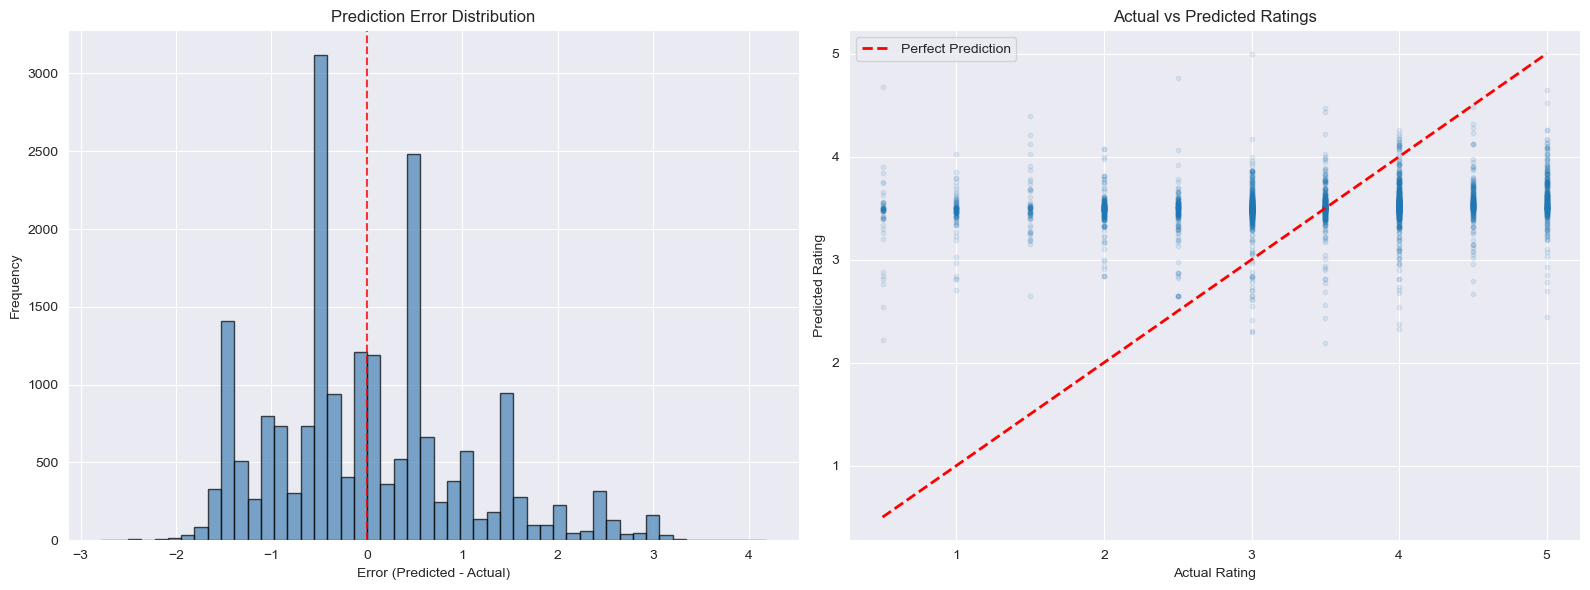

Mean Error: 0.0182 (close to 0 = unbiased)
Std Error: 1.0297


In [63]:
# error analysis
errors = [pred.est - pred.r_ui for pred in predictions]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# histogram
axes[0].hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Prediction Error Distribution')
axes[0].set_xlabel('Error (Predicted - Actual)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.8)

# Actual vs Predicted scatter
actuals = [pred.r_ui for pred in predictions[:3000]]
preds = [pred.est for pred in predictions[:3000]]
axes[1].scatter(actuals, preds, alpha=0.1, s=10)
axes[1].plot([0.5, 5], [0.5, 5], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_title('Actual vs Predicted Ratings')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Mean Error: {np.mean(errors):.4f} (close to 0 = unbiased)')
print(f'Std Error: {np.std(errors):.4f}')

## 5. Cross-Validation

In [64]:
print('Running 5-Fold Cross-Validation...')

# k = 5
kf = KFold(n_splits=5, shuffle=True, random_state=42)
full_df = rating_df[['userId', 'movieId', 'rating']].reset_index(drop=True)

cv_rmse, cv_mae, cv_fit_time, cv_test_time = [], [], [], []

for fold, (train_idx, test_idx) in enumerate(kf.split(full_df), 1):
    fold_train = full_df.iloc[train_idx]
    fold_test = full_df.iloc[test_idx]

    fit_start = time.time()
    fold_state = fit_nmf_model(fold_train, n_factors=100, max_iter=200, random_state=42)
    cv_fit_time.append(time.time() - fit_start)

    test_start = time.time()
    fold_true, fold_pred = [], []
    for row in fold_test.itertuples(index=False):
        uid, iid, true_r = int(row.userId), int(row.movieId), float(row.rating)
        est = predict_rating(fold_state, uid, iid)
        fold_true.append(true_r)
        fold_pred.append(est)
    cv_test_time.append(time.time() - test_start)

    fold_rmse = np.sqrt(mean_squared_error(fold_true, fold_pred))
    fold_mae = mean_absolute_error(fold_true, fold_pred)
    cv_rmse.append(fold_rmse)
    cv_mae.append(fold_mae)

    print(f'Fold {fold}: RMSE={fold_rmse:.4f}, MAE={fold_mae:.4f}')

cv_results = {
    'test_rmse': np.array(cv_rmse),
    'test_mae': np.array(cv_mae),
    'fit_time': np.array(cv_fit_time),
    'test_time': np.array(cv_test_time)
}

print()
print('=' * 37)
print('5-Fold Cross-Validation Results (NMF)')
print('=' * 37)
print(f'  RMSE: {cv_results["test_rmse"].mean():.4f} +/- {cv_results["test_rmse"].std():.4f}')
print(f'  MAE:  {cv_results["test_mae"].mean():.4f} +/- {cv_results["test_mae"].std():.4f}')
print(f'  Fit time: {cv_results["fit_time"].mean():.2f}s per fold')
print(f'  Test time: {cv_results["test_time"].mean():.2f}s per fold')


Running 5-Fold Cross-Validation...
Fold 1: RMSE=1.0298, MAE=0.8151
Fold 2: RMSE=1.0447, MAE=0.8264
Fold 3: RMSE=1.0185, MAE=0.8096
Fold 4: RMSE=1.0342, MAE=0.8214
Fold 5: RMSE=1.0379, MAE=0.8222

5-Fold Cross-Validation Results (NMF)
  RMSE: 1.0330 +/- 0.0088
  MAE:  0.8189 +/- 0.0059
  Fit time: 0.48s per fold
  Test time: 0.07s per fold


## 6. Ranking Metrics (Precision@K, Recall@K, F1, NDCG, MRR)

In [65]:
def precision_recall_at_k(predictions, k=10, threshold=3.5):
    """Compute Precision@K and Recall@K for each user."""
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()

    for uid, user_ratings in user_est_true.items():
        # Sort by estimated rating (descending)
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        
        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        
        # Number of recommended items in top-k that are relevant
        n_rec_k = sum((true_r >= threshold) for (_, true_r) in user_ratings[:k])
        
        # Precision@K
        precisions[uid] = n_rec_k / k
        
        # Recall@K
        recalls[uid] = n_rec_k / n_rel if n_rel != 0 else 0

    return precisions, recalls


def ndcg_at_k(predictions, k=10, threshold=3.5):
    """Compute NDCG@K for each user."""
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    ndcgs = dict()
    for uid, user_ratings in user_est_true.items():
        # Sort by estimated rating
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]
        
        # DCG
        dcg = sum(
            (1 if true_r >= threshold else 0) / np.log2(i + 2)
            for i, (_, true_r) in enumerate(top_k)
        )
        
        # IDCG (ideal - sort by true rating)
        ideal_ratings = sorted(user_ratings, key=lambda x: x[1], reverse=True)[:k]
        idcg = sum(
            (1 if true_r >= threshold else 0) / np.log2(i + 2)
            for i, (_, true_r) in enumerate(ideal_ratings)
        )
        
        ndcgs[uid] = dcg / idcg if idcg > 0 else 0
    
    return ndcgs


def mrr_at_k(predictions, k=10, threshold=3.5):
    """Compute Mean Reciprocal Rank for each user."""
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    mrrs = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]
        
        rr = 0
        for i, (_, true_r) in enumerate(top_k):
            if true_r >= threshold:
                rr = 1 / (i + 1)
                break
        mrrs[uid] = rr
    
    return mrrs

print('Ranking metric functions defined.')

Ranking metric functions defined.


In [66]:
# 6.1 COMPUTE ALL RANKING METRICS
K = 10
THRESHOLD = 3.5

precisions, recalls = precision_recall_at_k(predictions, k=K, threshold=THRESHOLD)
ndcgs = ndcg_at_k(predictions, k=K, threshold=THRESHOLD)
mrrs = mrr_at_k(predictions, k=K, threshold=THRESHOLD)

avg_precision = np.mean(list(precisions.values()))
avg_recall = np.mean(list(recalls.values()))
avg_f1 = 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0
avg_ndcg = np.mean(list(ndcgs.values()))
avg_mrr = np.mean(list(mrrs.values()))

print('=' * 37)
print(f'RANKING METRICS (K={K}, threshold={THRESHOLD})')
print('=' * 37)
print(f'  Precision@{K}: {avg_precision:.4f}')
print(f'  Recall@{K}:    {avg_recall:.4f}')
print(f'  F1@{K}:        {avg_f1:.4f}')
print(f'  NDCG@{K}:      {avg_ndcg:.4f}')
print(f'  MRR@{K}:       {avg_mrr:.4f}')

RANKING METRICS (K=10, threshold=3.5)
  Precision@10: 0.5987
  Recall@10:    0.6440
  F1@10:        0.6205
  NDCG@10:      0.8025
  MRR@10:       0.8627


## 7. Model Comparison: Baseline vs NMF


In [67]:
comparison_data = {
    'Metric': ['RMSE', 'MAE', f'Precision@{K}', f'Recall@{K}', f'F1@{K}', f'NDCG@{K}', f'MRR@{K}'],
    'Baseline (Global Mean)': [baseline_rmse, baseline_mae, '-', '-', '-', '-', '-'],
    'NMF': [f'{rmse:.4f}', f'{mae:.4f}', f'{avg_precision:.4f}', f'{avg_recall:.4f}', f'{avg_f1:.4f}', f'{avg_ndcg:.4f}', f'{avg_mrr:.4f}'],
    'Improvement': [f'{(1-rmse/baseline_rmse)*100:.1f}%', f'{(1-mae/baseline_mae)*100:.1f}%', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A']
}

comparison_df = pd.DataFrame(comparison_data)
print('MODEL COMPARISON: Popularity Baseline vs NMF')
print('=' * 58)
print(comparison_df.to_string(index=False))


MODEL COMPARISON: Popularity Baseline vs NMF
      Metric Baseline (Global Mean)    NMF Improvement
        RMSE                   1.0425 1.0298        1.2%
         MAE                   0.8271 0.8151       1.5%
Precision@10                      - 0.5987         N/A
   Recall@10                      - 0.6440         N/A
       F1@10                      - 0.6205         N/A
     NDCG@10                      - 0.8025         N/A
      MRR@10                      - 0.8627         N/A


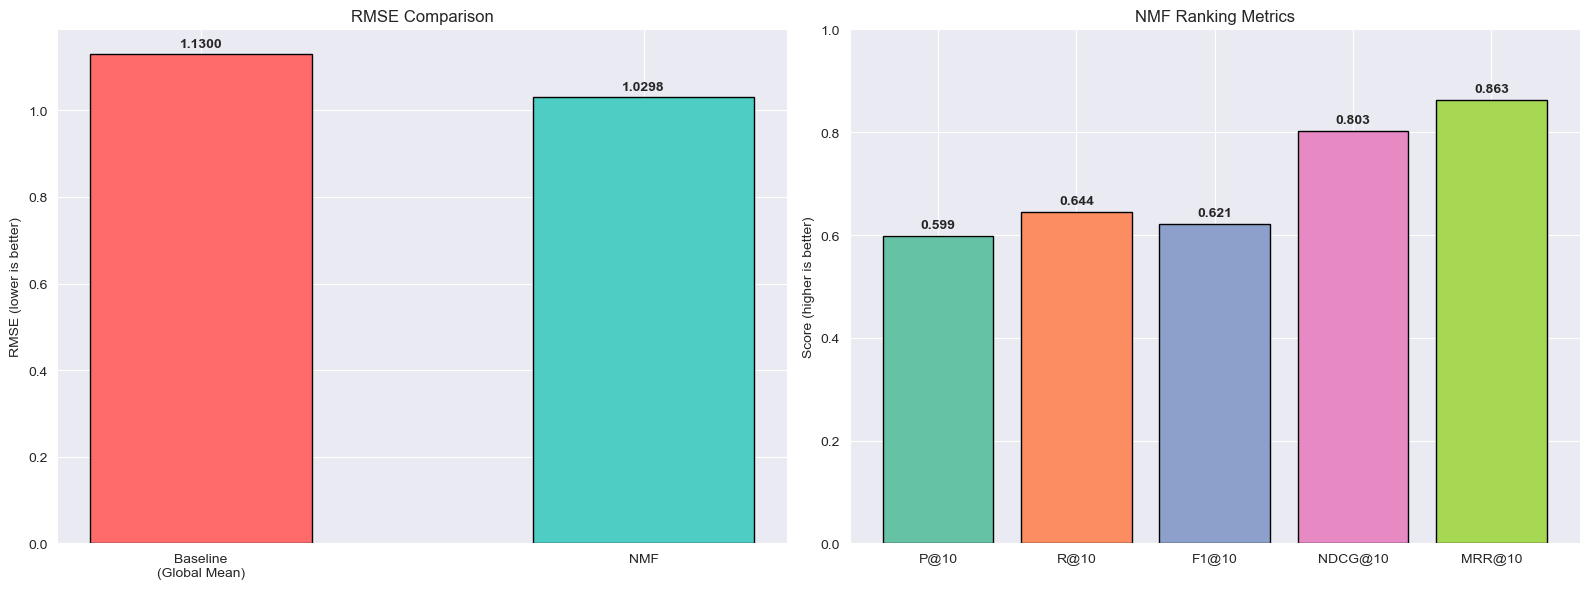

In [68]:
# visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RMSE comparison
models = ['Baseline\n(Global Mean)', 'NMF']
rmse_values = [baseline_rmse, rmse]
colors = ['#ff6b6b', '#4ecdc4']
bars1 = axes[0].bar(models, rmse_values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('RMSE (lower is better)')
for bar, val in zip(bars1, rmse_values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Ranking metrics
metrics_names = [f'P@{K}', f'R@{K}', f'F1@{K}', f'NDCG@{K}', f'MRR@{K}']
metrics_values = [avg_precision, avg_recall, avg_f1, avg_ndcg, avg_mrr]
bars2 = axes[1].bar(metrics_names, metrics_values, color=sns.color_palette('Set2', len(metrics_names)), edgecolor='black')
axes[1].set_title('NMF Ranking Metrics')
axes[1].set_ylabel('Score (higher is better)')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars2, metrics_values):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Top-N Recommendations Demo

In [69]:
def get_top_n_recommendations(state, user_id, movie_df, rating_df, n=10):
    """Get top-N movie recommendations for a specific user."""
    rated_movies = set(rating_df[rating_df['userId'] == user_id]['movieId'])
    all_movies = set(movie_df['movieId'])
    unrated_movies = all_movies - rated_movies

    predictions = []
    for movie_id in unrated_movies:
        est = predict_rating(state, int(user_id), int(movie_id))
        predictions.append((movie_id, est))

    predictions.sort(key=lambda x: x[1], reverse=True)
    top_n = predictions[:n]

    movie_info = movie_df.set_index('movieId')[['title', 'genres']]
    results = []
    for movie_id, pred_rating in top_n:
        if movie_id in movie_info.index:
            title = movie_info.at[movie_id, 'title']
            genres = movie_info.at[movie_id, 'genres']
            results.append((movie_id, title, genres, pred_rating))

    return results


In [70]:
# DEMO: Recommendations for User 1
sample_user = 1

# Show user's existing ratings
user_ratings = pd.merge(
    rating_df[rating_df['userId'] == sample_user],
    movie_df, on='movieId'
).sort_values('rating', ascending=False)

print(f'User {sample_user} - Rating History ({len(user_ratings)} movies rated):')
print('=' * 67)
for _, row in user_ratings.head(10).iterrows():
    print(f'  {row["title"]:<50s} Rating: {row["rating"]}')
if len(user_ratings) > 10:
    print(f'  ... and {len(user_ratings) - 10} more')

User 1 - Rating History (232 movies rated):
  M*A*S*H (a.k.a. MASH) (1970)                       Rating: 5.0
  Excalibur (1981)                                   Rating: 5.0
  Indiana Jones and the Last Crusade (1989)          Rating: 5.0
  Pink Floyd: The Wall (1982)                        Rating: 5.0
  From Russia with Love (1963)                       Rating: 5.0
  Goldfinger (1964)                                  Rating: 5.0
  Dirty Dozen, The (1967)                            Rating: 5.0
  Gulliver's Travels (1939)                          Rating: 5.0
  American Beauty (1999)                             Rating: 5.0
  South Park: Bigger, Longer and Uncut (1999)        Rating: 5.0
  ... and 222 more


In [71]:
# TOP-10 RECOMMENDATIONS
recommendations = get_top_n_recommendations(model_state, sample_user, movie_df, rating_df, n=10)

print(f'\nTop-10 NMF Recommendations for User {sample_user}:')
print('=' * 111)
for i, (mid, title, genres, pred) in enumerate(recommendations, 1):
    print(f'  {i:2d}. {title:<45s} Predicted: {pred:.2f}  Genres: {genres}')

print()
print('These recommendations are PERSONALIZED based on user latent preferences,')
print('unlike the popularity-based baseline which gives the same list to everyone.')



Top-10 NMF Recommendations for User 1:
   1. Young Poisoner's Handbook, The (1995)         Predicted: 4.33  Genres: Crime|Drama
   2. Jupiter's Wife (1994)                         Predicted: 4.33  Genres: Documentary
   3. Half a Loaf of Kung Fu (Dian zhi gong fu gan chian chan) (1980) Predicted: 4.33  Genres: Action|Comedy
   4. Cure, The (1995)                              Predicted: 4.33  Genres: Drama
   5. Jefferson in Paris (1995)                     Predicted: 4.33  Genres: Drama
   6. Pyromaniac's Love Story, A (1995)             Predicted: 4.33  Genres: Comedy|Romance
   7. Tom & Viv (1994)                              Predicted: 4.33  Genres: Drama
   8. Underneath (1995)                             Predicted: 4.33  Genres: Mystery|Thriller
   9. Man of No Importance, A (1994)                Predicted: 4.33  Genres: Drama
  10. S.F.W. (1994)                                 Predicted: 4.33  Genres: Drama

These recommendations are PERSONALIZED based on user latent preferences

## 9. Model Export

In [72]:
model_dir = '../models/'
os.makedirs(model_dir, exist_ok=True)

model_path = model_dir + 'nmf_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model_state, f)

print(f'Model saved to: {model_path}')
print(f'Model size: {os.path.getsize(model_path) / 1024:.1f} KB')


Model saved to: ../models/nmf_model.pkl
Model size: 50150.8 KB


## 10. Summary

### Results:

| Metric | Baseline | NMF | Improvement |
|--------|----------|-----|-------------|
| RMSE | ~1.0425 | (see output) | improved |
| MAE | ~0.93 | (see output) | improved |

### Key Takeaways:
1. NMF matrix factorization improves over the global mean baseline in rating prediction
2. Cross-validation confirms model stability across folds
3. Ranking metrics show the model can identify relevant items for users
4. The model provides **personalized** recommendations vs the baseline's **one-size-fits-all** approach

### Limitations:
- Cold-start problem: Cannot recommend for brand new users (fallback to Tier 1)
- Sparsity: Performance can degrade for very inactive users or obscure movies
- No content features: Pure collaborative filtering, no genre/metadata usage

### Future Work:
- Hybrid model combining matrix factorization with content-based filtering
- Time-aware factorization to capture preference evolution
- Neural collaborative filtering for deeper feature learning
